# Phase 2 Validation — Preprocessing Pipeline

This notebook validates `src/preprocessing/` by running **real records** from `sample_targets.json` through each module step by step and inspecting the input vs output visually.

**Three records chosen to cover all cases:**

| Line | Schema  | Caption                              | Why chosen |
|------|---------|--------------------------------------|------------|
| 0    | Company | Myanmar Yatai International Holding  | Has names, notes, nested sanctions, addressEntity |
| 8    | Vessel  | DONG CHANG                           | Has IMO number (exact-match identifier) |
| 9    | Person  | Michael Kuajien                      | Has multiple name variants, alias |

**Validation checks:**
1. Parser yields clean dicts
2. Names are normalized but NOT lemmatized
3. Notes/descriptions ARE lemmatized
4. IMO numbers appear in `identifiers`, NOT in `tokens`
5. Nested `sanctions` are flattened into `text_blob`
6. `text_blob` is non-empty for all records
7. `documents.jsonl` output matches what `build_document()` produces

In [1]:
# Setup
import json
import sys
import os
from pathlib import Path
import pandas as pd

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

# Locate project root
def find_root():
    for key in ('IR_PROJECT_ROOT', 'VSCODE_WORKSPACE_FOLDER', 'CURSOR_WORKSPACE_FOLDER'):
        v = os.environ.get(key)
        if v:
            p = Path(v)
            if (p / 'data' / 'raw_data').exists():
                return p
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'data' / 'raw_data').exists():
            return base
    raise FileNotFoundError('Cannot find project root')

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SAMPLE_PATH  = ROOT / 'data' / 'raw_data'         / 'sample_targets.json'
OUTPUT_PATH  = ROOT / 'data' / 'json_format_data' / 'subset_100k' / 'documents.jsonl'
STATS_PATH   = ROOT / 'data' / 'json_format_data' / 'subset_100k' / 'stats.json'

print(f'Project root : {ROOT}')
print(f'Sample file  : {SAMPLE_PATH.exists()}')
print(f'Output file  : {OUTPUT_PATH.exists()}')

Project root : /Users/alireza/Library/CloudStorage/GoogleDrive-ali.esterabi@gmail.com/My Drive/QMUL_temr_2/IR_project
Sample file  : True
Output file  : True


---
## Step 1 — Load the three validation records (raw)

In [2]:
with open(SAMPLE_PATH) as f:
    all_sample = [json.loads(l) for l in f]

# Line 0 = Company (Myanmar Yatai), Line 8 = Vessel (DONG CHANG), Line 9 = Person (Michael Kuajien)
RECORDS = {
    'Company': all_sample[0],
    'Vessel':  all_sample[8],
    'Person':  all_sample[9],
}

for schema, rec in RECORDS.items():
    print(f"{schema:10s}  {rec['id']}  →  {rec['caption']}")

Company     NK-223CQDBzp8MRkdJMDiqXn3  →  Myanmar Yatai International Holding Group Co., LTD.
Vessel      NK-22C9zkXEo48ioJPccyPR4c  →  DONG CHANG
Person      NK-22HtK7WrxZ2sU3rmhz6PuZ  →  Michael Kuajien


In [3]:
# Inspect full raw structure of the Company record
print("=== RAW Company record (Myanmar Yatai) ===")
print(json.dumps(RECORDS['Company'], indent=2, ensure_ascii=False)[:2000])
print('...(truncated)')

=== RAW Company record (Myanmar Yatai) ===
{
  "id": "NK-223CQDBzp8MRkdJMDiqXn3",
  "caption": "Myanmar Yatai International Holding Group Co., LTD.",
  "schema": "Company",
  "referents": [
    "oc-companies-mm-1fc-2016-2017-kyn",
    "ofac-pr-eeb375713cf08ae562a6c803379026faec3559b2",
    "ofac-pr-d380717bd7ea466cc6be435f06d7765b4bc74cbb",
    "usgsa-s4mrxdbks",
    "ofac-pr-6ad9ad0a10350419f24b0794dbe9f530abd81b59",
    "usgsa-s4mrxdbkr",
    "usgsa-s4mrxdbkq",
    "usgsa-s4mrwvjp8",
    "ofac-54742"
  ],
  "datasets": [
    "us_trade_csl",
    "opencorporates",
    "us_ofac_sdn",
    "us_sam_exclusions",
    "ext_us_ofac_press_releases"
  ],
  "origin": [
    "gpt-4o",
    "SAM_Exclusions_Public_Extract_V2_26058.CSV"
  ],
  "first_seen": "2025-09-08T14:10:01",
  "last_seen": "2026-03-21T12:11:28",
  "last_change": "2026-03-17T16:05:27",
  "properties": {
    "country": [
      "mm"
    ],
    "sourceUrl": [
      "https://home.treasury.gov/news/press-releases/sb0237",
      "https:/

---
## Step 2 — Run the Parser

`parser.stream_records()` opens the file and yields one dict per line without loading the whole file.
Here we use it directly on `sample_targets.json` to confirm it works on real data.

In [4]:
from src.preprocessing.parser import stream_records

parsed = list(stream_records(SAMPLE_PATH, max_records=10, show_progress=False))

print(f"Parser yielded {len(parsed)} records\n")
print(f"{'#':<4} {'Schema':<14} {'ID':<30} {'Caption'}")
print('-' * 80)
for i, rec in enumerate(parsed):
    print(f"{i:<4} {rec['schema']:<14} {rec['id']:<30} {rec['caption'][:35]}")

Parser yielded 10 records

#    Schema         ID                             Caption
--------------------------------------------------------------------------------
0    Company        NK-223CQDBzp8MRkdJMDiqXn3      Myanmar Yatai International Holding
1    Company        NK-223yQP6hRaMuiALDCJ6xbY      Товариство з обмеженою відповідальн
2    Person         NK-224TRezPqwzhQZ37exWxtX      SANAVBARI NIKITENKO
3    Company        NK-226GXBdQ5p6NjgrTpTQNVW      Open Joint Stock Company “Elektrost
4    Company        NK-228ZdYZVXaZBSBgVwapnks      Приватне підприємство "Магістар-СГ"
5    Company        NK-228jBYSTdUSvbZvsKsiHh6      Акціонерне товариство "Електроагрег
6    LegalEntity    NK-229j9NEWBexje4PuNpeHxg      MICHAEL DAVID MUMMERT
7    Person         NK-22BiLDQqi5mhKfDeYuqs23      ARNITA LEFF
8    Vessel         NK-22C9zkXEo48ioJPccyPR4c      DONG CHANG
9    Person         NK-22HtK7WrxZ2sU3rmhz6PuZ      Michael Kuajien


---
## Step 3 — Run TextProcessor step by step

This is the core of the preprocessing. We show:
- **Names**: normalized only (no lemmatization)
- **Notes/descriptions**: normalized + lemmatized
- **Identifiers**: completely untouched

In [5]:
from src.preprocessing.text_processing import TextProcessor

tp = TextProcessor()
print('TextProcessor loaded.')

TextProcessor loaded.


In [6]:
# --- Check 1: Names are normalized but NOT lemmatized ---
print("CHECK 1: Name normalization (no lemmatization)\n")

for label, rec in RECORDS.items():
    props = rec.get('properties', {})
    raw_names = props.get('name', []) + props.get('alias', [])
    normalized = tp.build_name_text(raw_names)
    print(f"[{label}] {rec['caption']}")
    print(f"  RAW names  : {raw_names}")
    print(f"  NORMALIZED : {normalized}")
    print()

CHECK 1: Name normalization (no lemmatization)

[Company] Myanmar Yatai International Holding Group Co., LTD.
  RAW names  : ['Yatai New City', 'Myanmar Yatai International Holding Group Co., Ltd', 'SHWE KOKKO SPECIAL ECONOMIC ZONE', 'Myanmar Yatai International Holding Group Co., LTD.', 'YATAI SMART INDUSTRIAL NEW CITY', 'Yatai Smart Industrial New City', 'Yatai New City', 'Shwe Kokko Special Economic Zone']
  NORMALIZED : yatai new city myanmar yatai international holding group co ltd shwe kokko special economic zone myanmar yatai international holding group co ltd yatai smart industrial new city yatai smart industrial new city yatai new city shwe kokko special economic zone

[Vessel] DONG CHANG
  RAW names  : ['DONG CHANG']
  NORMALIZED : dong chang

[Person] Michael Kuajien
  RAW names  : ['Michael Kuajien', 'MICHAEL KUAJIEN DUER MAYOK', 'KUAJIEN, Michael', 'MICHAEL KUAJIAN', 'Michael Kuajian', 'Michael Kuajien Duer Mayok']
  NORMALIZED : michael kuajien michael kuajien duer mayok 

In [7]:
# --- Check 2: Notes/descriptions ARE lemmatized ---
print("CHECK 2: Description lemmatization\n")

for label, rec in RECORDS.items():
    props = rec.get('properties', {})
    raw_notes = props.get('notes', []) + props.get('description', [])
    lemmatized = tp.build_desc_text(raw_notes)
    print(f"[{label}] {rec['caption']}")
    print(f"  RAW notes  : {raw_notes}")
    print(f"  LEMMATIZED : {lemmatized[:200]}")
    print()

CHECK 2: Description lemmatization

[Company] Myanmar Yatai International Holding Group Co., LTD.
  RAW notes  : ['(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART INDUSTRIAL NEW CITY)', '(also MYANMAR YATAI INTERNATIONAL HOLDING GROUP CO., LTD.)']
  LEMMATIZED : shwe kokko special economic zone yatai new city yatai smart industrial new city myanmar yatai international holding group co ltd

[Vessel] DONG CHANG
  RAW notes  : []
  LEMMATIZED : 

[Person] Michael Kuajien
  RAW notes  : ['(also MICHAEL KUAJIAN, MICHAEL KUAJIEN DUER MAYOK)', '(also MICHAEL KUAJIEN)']
  LEMMATIZED : michael kuajian michael kuajien duer mayok michael kuajien



In [8]:
# --- Check 3: Sanctions nested objects are flattened ---
print("CHECK 3: Sanctions flattening\n")

for label, rec in RECORDS.items():
    props = rec.get('properties', {})
    sanctions = [s for s in props.get('sanctions', []) if isinstance(s, dict)]
    if not sanctions:
        print(f"[{label}] No sanctions nested objects\n")
        continue
    
    s0_props = sanctions[0].get('properties', {})
    flattened = tp.build_sanctions_text(sanctions)
    
    print(f"[{label}] {rec['caption']}")
    print(f"  Sanctions count  : {len(sanctions)}")
    print(f"  authority (raw)  : {s0_props.get('authority', [])}")
    print(f"  reason (raw)     : {str(s0_props.get('reason', []))[:80]}")
    print(f"  FLATTENED TEXT   : {flattened[:200]}")
    print()

CHECK 3: Sanctions flattening

[Company] Myanmar Yatai International Holding Group Co., LTD.
  Sanctions count  : 5
  authority (raw)  : ['Office of Foreign Assets Control']
  reason (raw)     : ['Executive Order 13818 (Global Magnitsky)']
  FLATTENED TEXT   : office foreign asset control executive order global magnitsky glomag treas ofac treas ofac treas ofac treas ofac

[Vessel] DONG CHANG
  Sanctions count  : 1
  authority (raw)  : ['Tokyo Memorandum of Understanding']
  reason (raw)     : ['14104 - POLLUTION PREVENTION - MARPOL ANNEX I - Oil filtering equipment (no re
  FLATTENED TEXT   : tokyo memorandum understand pollution prevention marpol annex oil filtering equipment responsibility ro water weathertight condition door responsibility ro

[Person] Michael Kuajien
  Sanctions count  : 4
  authority (raw)  : ['Office of Foreign Assets Control']
  reason (raw)     : ['Executive Order 13818 (Global Magnitsky)']
  FLATTENED TEXT   : office foreign asset control executive order globa

In [9]:
# --- Check 4: IMO number stays OUT of tokens ---
print("CHECK 4: Identifier isolation (Vessel — DONG CHANG)\n")

vessel = RECORDS['Vessel']
props  = vessel.get('properties', {})
imo    = props.get('imoNumber', [])
mmsi   = props.get('mmsi', [])

print(f"  Raw imoNumber : {imo}")
print(f"  Raw mmsi      : {mmsi}")

# The identifier should NOT flow through build_name_text or build_desc_text
name_text = tp.build_name_text(props.get('name', []))
desc_text = tp.build_desc_text(props.get('notes', []))
combined  = name_text + ' ' + desc_text

imo_in_text = any(i.lower() in combined.lower() for i in imo)
print(f"\n  Combined name+notes text: '{combined}'")
print(f"  IMO9553359 present in text? {imo_in_text}  ← should be FALSE")

CHECK 4: Identifier isolation (Vessel — DONG CHANG)

  Raw imoNumber : ['IMO9553359']
  Raw mmsi      : []

  Combined name+notes text: 'dong chang '
  IMO9553359 present in text? False  ← should be FALSE


---
## Step 4 — Run build_document() — full flatten

This is the function that produces the final output dict for each entity.

In [10]:
from src.preprocessing.document_builder import build_document

processed = {label: build_document(rec, tp) for label, rec in RECORDS.items()}

for label, doc in processed.items():
    print(f"{'='*70}")
    print(f"  [{label}]  {doc['caption']}")
    print(f"{'='*70}")
    print(f"  doc_id      : {doc['doc_id']}")
    print(f"  schema      : {doc['schema']}")
    print(f"  text_blob   : {doc['text_blob'][:200]}")
    print(f"  tokens ({len(doc['tokens']):3d}) : {doc['tokens'][:10]}")
    print(f"  identifiers : {doc['identifiers']}")
    print(f"  metadata    : {doc['metadata']}")
    print()

  [Company]  Myanmar Yatai International Holding Group Co., LTD.
  doc_id      : NK-223CQDBzp8MRkdJMDiqXn3
  schema      : Company
  text_blob   : yatai new city myanmar yatai international holding group co ltd shwe kokko special economic zone myanmar yatai international holding group co ltd yatai smart industrial new city yatai smart industrial
  tokens ( 97) : ['yatai', 'new', 'city', 'myanmar', 'yatai', 'international', 'holding', 'group', 'co', 'ltd']
  identifiers : {'registrationNumber': ['103919088'], 'uniqueEntityId': ['PW2XZT68KVW9', 'PW3LMJ5YB3M3', 'PW2USM6LNCJ9', 'GQBPAV1TFF41']}
  metadata    : {'country': ['mm'], 'programId': ['US-GLOMAG'], 'datasets': ['us_trade_csl', 'opencorporates', 'us_ofac_sdn', 'us_sam_exclusions', 'ext_us_ofac_press_releases']}

  [Vessel]  DONG CHANG
  doc_id      : NK-22C9zkXEo48ioJPccyPR4c
  schema      : Vessel
  text_blob   : dong chang mare detained tokyo memorandum understand pollution prevention marpol annex oil filtering equipment responsi

In [11]:
# Side-by-side: RAW properties vs processed fields — Company record
company_raw = RECORDS['Company']['properties']
company_doc = processed['Company']

rows = []
for field in ['name', 'alias', 'notes', 'topics', 'imoNumber', 'sanctions', 'addressEntity']:
    raw_val = company_raw.get(field, [])
    if field == 'sanctions':
        raw_str = f"{len(raw_val)} nested object(s)"
    elif field == 'addressEntity':
        raw_str = f"{len(raw_val)} nested object(s)"
    else:
        raw_str = str(raw_val)[:80]
    rows.append({'field': field, 'raw_value': raw_str})

df = pd.DataFrame(rows)

print("RAW properties (Company — Myanmar Yatai):")
print(df.to_string(index=False))
print()
print(f"→ text_blob ({len(company_doc['text_blob'].split())} tokens):")
print(f"  {company_doc['text_blob'][:300]}")

RAW properties (Company — Myanmar Yatai):
        field                                                                        raw_value
         name ['Yatai New City', 'Myanmar Yatai International Holding Group Co., Ltd', 'SHWE K
        alias ['Yatai Smart Industrial New City', 'Yatai New City', 'Shwe Kokko Special Econom
        notes ['(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART INDUSTRIAL
       topics                                                        ['sanction', 'debarment']
    imoNumber                                                                               []
    sanctions                                                               5 nested object(s)
addressEntity                                                               2 nested object(s)

→ text_blob (97 tokens):
  yatai new city myanmar yatai international holding group co ltd shwe kokko special economic zone myanmar yatai international holding group co ltd yatai smart industrial n

---
## Step 5 — Validate the documents.jsonl output

Check that what the pipeline wrote to disk matches what `build_document()` produces.

In [12]:
# Load stats.json
with open(STATS_PATH) as f:
    stats = json.load(f)

print("Pipeline stats (from stats.json):")
print(json.dumps(stats, indent=2))

Pipeline stats (from stats.json):
{
  "source_file": "/Users/alireza/Library/CloudStorage/GoogleDrive-ali.esterabi@gmail.com/My Drive/QMUL_tem_2/IR_project/data/raw_data/targets.nested.json",
  "output_dir": "data/processed/subset_100k",
  "max_records": 100000,
  "total_processed": 100000,
  "schema_counts": {
    "Person": 58839,
    "Company": 23520,
    "LegalEntity": 6683,
    "Vessel": 5848,
    "Organization": 4852,
    "Airplane": 243,
    "Security": 5,
    "PublicBody": 5,
    "Address": 5
  },
  "avg_token_count": 70.9,
  "empty_blob_count": 0,
  "has_identifiers": 58008,
  "elapsed_seconds": 606.11,
  "records_per_second": 165.0
}


In [13]:
# Spot-check: find our three validation records in documents.jsonl by doc_id
target_ids = {rec['id'] for rec in RECORDS.values()}
found = {}

with open(OUTPUT_PATH) as f:
    for line in f:
        doc = json.loads(line)
        if doc['doc_id'] in target_ids:
            found[doc['doc_id']] = doc
        if len(found) == len(target_ids):
            break

print(f"Found {len(found)}/{len(target_ids)} validation records in documents.jsonl\n")
for rec_id, doc in found.items():
    print(f"  {doc['doc_id']}  [{doc['schema']}]  {doc['caption']}")
    print(f"    tokens ({len(doc['tokens'])}): {doc['tokens'][:8]}")
    print(f"    identifiers: {doc['identifiers']}")
    print()

Found 3/3 validation records in documents.jsonl

  NK-223CQDBzp8MRkdJMDiqXn3  [Company]  Myanmar Yatai International Holding Group Co., LTD.
    tokens (97): ['yatai', 'new', 'city', 'myanmar', 'yatai', 'international', 'holding', 'group']
    identifiers: {'registrationNumber': ['103919088'], 'uniqueEntityId': ['PW2XZT68KVW9', 'PW3LMJ5YB3M3', 'PW2USM6LNCJ9', 'GQBPAV1TFF41']}

  NK-22C9zkXEo48ioJPccyPR4c  [Vessel]  DONG CHANG
    tokens (22): ['dong', 'chang', 'mare', 'detained', 'tokyo', 'memorandum', 'understand', 'pollution']
    identifiers: {'imoNumber': ['IMO9553359']}

  NK-22HtK7WrxZ2sU3rmhz6PuZ  [Person]  Michael Kuajien
    tokens (45): ['michael', 'kuajien', 'michael', 'kuajien', 'duer', 'mayok', 'kuajien', 'michael']
    identifiers: {}



In [14]:
# Compare: pipeline output vs fresh build_document() output for DONG CHANG
vessel_id  = RECORDS['Vessel']['id']
from_disk  = found.get(vessel_id)
from_live  = processed['Vessel']

print("DONG CHANG — disk output vs live build_document()\n")
for key in ['text_blob', 'tokens', 'identifiers', 'metadata']:
    disk_val = from_disk.get(key) if from_disk else 'NOT FOUND'
    live_val = from_live.get(key)
    match = '✓' if disk_val == live_val else '✗ MISMATCH'
    if key == 'text_blob':
        print(f"  {key:15s}: {match}")
        print(f"    disk: {str(disk_val)[:100]}")
        print(f"    live: {str(live_val)[:100]}")
    else:
        print(f"  {key:15s}: {match}  →  {disk_val}")

DONG CHANG — disk output vs live build_document()

  text_blob      : ✓
    disk: dong chang mare detained tokyo memorandum understand pollution prevention marpol annex oil filtering
    live: dong chang mare detained tokyo memorandum understand pollution prevention marpol annex oil filtering
  tokens         : ✓  →  ['dong', 'chang', 'mare', 'detained', 'tokyo', 'memorandum', 'understand', 'pollution', 'prevention', 'marpol', 'annex', 'oil', 'filtering', 'equipment', 'responsibility', 'ro', 'water', 'weathertight', 'condition', 'door', 'responsibility', 'ro']
  identifiers    : ✓  →  {'imoNumber': ['IMO9553359']}
  metadata       : ✓  →  {'country': [], 'programId': [], 'datasets': ['tokyo_mou_detention']}


---
## Step 6 — Bulk quality checks on documents.jsonl

Sample 1,000 documents from the output file and run statistical checks.

In [15]:
from collections import Counter

sample_docs = []
with open(OUTPUT_PATH) as f:
    for i, line in enumerate(f):
        if i >= 1000:
            break
        sample_docs.append(json.loads(line))

print(f"Loaded {len(sample_docs)} docs for bulk checks\n")

# --- Quality metrics ---
empty_blobs   = sum(1 for d in sample_docs if not d['text_blob'])
has_ids       = sum(1 for d in sample_docs if d['identifiers'])
token_lengths = [len(d['tokens']) for d in sample_docs]
schema_dist   = Counter(d['schema'] for d in sample_docs)

print(f"Empty text_blobs  : {empty_blobs} / {len(sample_docs)}  ← should be 0")
print(f"Has identifiers   : {has_ids} / {len(sample_docs)}")
print(f"Min tokens/doc    : {min(token_lengths)}")
print(f"Max tokens/doc    : {max(token_lengths)}")
print(f"Avg tokens/doc    : {sum(token_lengths)/len(token_lengths):.1f}")
print(f"\nSchema distribution (1K sample):")
for schema, count in schema_dist.most_common():
    print(f"  {schema:<20} {count:>5}  ({count/len(sample_docs)*100:.1f}%)")

Loaded 1000 docs for bulk checks

Empty text_blobs  : 0 / 1000  ← should be 0
Has identifiers   : 625 / 1000
Min tokens/doc    : 3
Max tokens/doc    : 2608
Avg tokens/doc    : 61.2

Schema distribution (1K sample):
  Person                 519  (51.9%)
  Company                254  (25.4%)
  LegalEntity             90  (9.0%)
  Vessel                  71  (7.1%)
  Organization            61  (6.1%)
  Airplane                 5  (0.5%)


In [16]:
# --- IMO number isolation check (bulk) ---
# For every Vessel doc, verify imoNumber is in identifiers and NOT in tokens
vessels = [d for d in sample_docs if d['schema'] == 'Vessel']
violations = []

for doc in vessels:
    for imo_val in doc['identifiers'].get('imoNumber', []):
        if imo_val.lower() in doc['text_blob'].lower():
            violations.append((doc['doc_id'], imo_val))

print(f"Vessel records in sample: {len(vessels)}")
print(f"IMO numbers in identifiers: {sum(len(d['identifiers'].get('imoNumber',[])) for d in vessels)}")
print(f"IMO values leaking into text_blob: {len(violations)}  ← should be 0")
if violations:
    print("  Violations:", violations[:5])

Vessel records in sample: 71
IMO numbers in identifiers: 71
IMO values leaking into text_blob: 0  ← should be 0


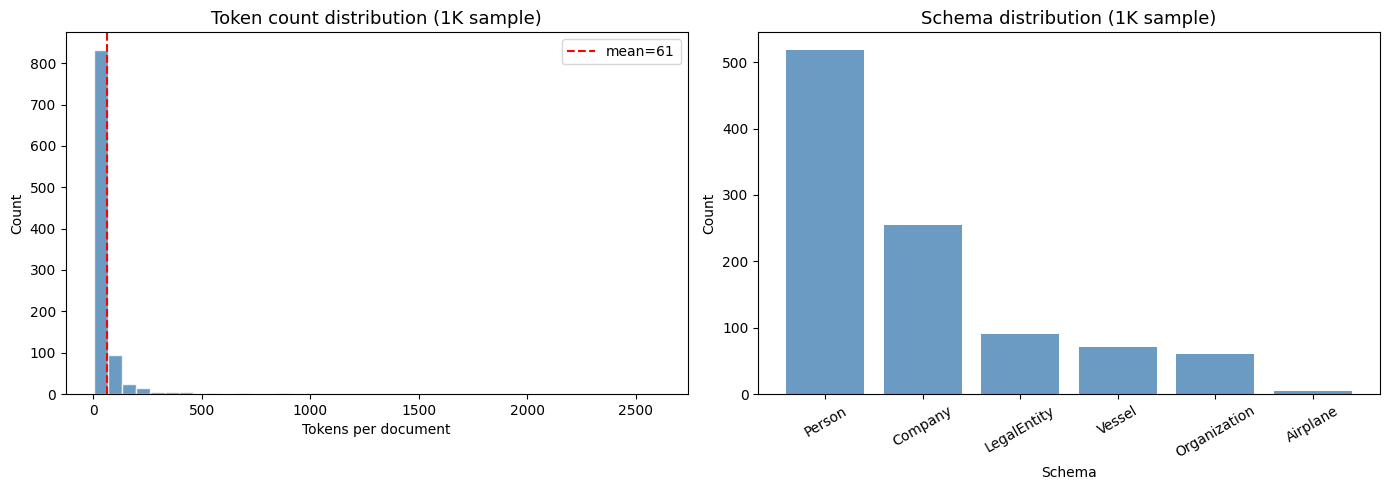

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token length distribution
axes[0].hist(token_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(sum(token_lengths)/len(token_lengths), color='red',
                linestyle='--', label=f'mean={sum(token_lengths)/len(token_lengths):.0f}')
axes[0].set_title('Token count distribution (1K sample)', fontsize=13)
axes[0].set_xlabel('Tokens per document')
axes[0].set_ylabel('Count')
axes[0].legend()

# Schema distribution
schemas = [s for s, _ in schema_dist.most_common()]
counts  = [c for _, c in schema_dist.most_common()]
axes[1].bar(schemas, counts, color='steelblue', alpha=0.8)
axes[1].set_title('Schema distribution (1K sample)', fontsize=13)
axes[1].set_xlabel('Schema')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Summary — Phase 2 Validation Checklist

Run the cell below to print the final checklist. All items should show ✓.

In [18]:
print("=" * 60)
print("PHASE 2 VALIDATION CHECKLIST")
print("=" * 60)

checks = []

# 1. documents.jsonl exists
checks.append(('documents.jsonl exists', OUTPUT_PATH.exists()))

# 2. Correct record count
checks.append(('100,000 records processed', stats.get('total_processed') == 100_000))

# 3. No empty text blobs
checks.append(('Zero empty text_blobs', stats.get('empty_blob_count') == 0))

# 4. Reasonable avg token count (expect 50-150)
avg = stats.get('avg_token_count', 0)
checks.append((f'Avg tokens/doc reasonable ({avg})', 30 <= avg <= 300))

# 5. Validation records found in output
checks.append(('All 3 validation records found in output', len(found) == 3))

# 6. IMO numbers not leaking into tokens
checks.append(('IMO numbers not in text_blob (bulk)', len(violations) == 0))

# 7. Schema distribution looks right (Person should be ~50-85%)
person_pct = schema_dist.get('Person', 0) / len(sample_docs) * 100
checks.append((f'Person schema dominant ({person_pct:.0f}%)', 50 <= person_pct <= 90))

# 8. Vessel has identifiers
vessel_doc = processed.get('Vessel', {})
checks.append(('Vessel identifiers preserved', bool(vessel_doc.get('identifiers'))))

# 9. Disk == live for DONG CHANG
if from_disk:
    match = from_disk.get('text_blob') == from_live.get('text_blob')
else:
    match = False
checks.append(('Disk output matches live build_document()', match))

print()
all_pass = True
for label, passed in checks:
    icon = '✓' if passed else '✗'
    print(f"  {icon}  {label}")
    if not passed:
        all_pass = False

print()
if all_pass:
    print("ALL CHECKS PASSED — Phase 2 is complete.")
    print("Ready to proceed to Phase 5: BM25 Indexing.")
else:
    print("Some checks FAILED — review the cells above.")

PHASE 2 VALIDATION CHECKLIST

  ✓  documents.jsonl exists
  ✓  100,000 records processed
  ✓  Zero empty text_blobs
  ✓  Avg tokens/doc reasonable (70.9)
  ✓  All 3 validation records found in output
  ✓  IMO numbers not in text_blob (bulk)
  ✓  Person schema dominant (52%)
  ✓  Vessel identifiers preserved
  ✓  Disk output matches live build_document()

ALL CHECKS PASSED — Phase 2 is complete.
Ready to proceed to Phase 5: BM25 Indexing.
